In [26]:
# Imports
import os
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import joblib
import random
import pickle
import numpy as np
from statistics import mean, stdev
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix, f1_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import RepeatedStratifiedKFold
from itertools import product
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    average_precision_score, confusion_matrix
)
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from statistics import mean, stdev
import numpy as np
import torch, random, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import config
from preprocessing_utils import *
from model_utils import *

# Set seeds for reproducibility
set_random_seed(42, deterministic=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [27]:
class MultimodalDataset(Dataset):
    def __init__(self, X, y, clinical_cols, mrna_cols, mutation_cols):
        # Split modalities
        self.clinical = X[clinical_cols].to_numpy()
        self.mrna = X[mrna_cols].to_numpy().astype(float)
        self.mutation = X[mutation_cols].to_numpy().astype(float)
        self.labels = y.to_numpy().astype(float)
                
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.clinical[idx], dtype=torch.float32),
            torch.tensor(self.mrna[idx], dtype=torch.float32),
            torch.tensor(self.mutation[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )

In [28]:
def evaluate_with_threshold(model, loader, threshold):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for clin, mrna, mut, y in loader:
            clin, mrna, mut, y = clin.to(device), mrna.to(device), mut.to(device), y.to(device)
            probs = torch.sigmoid(model(clin, mrna, mut)).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    preds = (all_probs >= threshold).astype(float)

    metrics = {
        'auroc': roc_auc_score(all_labels, all_probs),
        'auprc': average_precision_score(all_labels, all_probs),
        'precision': precision_score(all_labels, preds, zero_division=0),
        'recall': recall_score(all_labels, preds, zero_division=0),
        'f1': f1_score(all_labels, preds, zero_division=0)
    }
    return metrics

In [29]:
X_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_train.joblib"))
y_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_train.joblib"))
X_val = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_val.joblib"))
y_val = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_val.joblib"))
X_test = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_test.joblib"))
y_test = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_test.joblib"))
clinical_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "clinical_cols.joblib"))
mrna_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "mrna_cols.joblib"))
mutation_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "mutation_cols.joblib"))

X_testval = pd.concat([X_val, X_test], axis=0).reset_index(drop=True)
y_testval = pd.concat([y_val, y_test], axis=0).reset_index(drop=True)

# Split modalities
clinical_train = X_train[clinical_cols]
mrna_train = X_train[mrna_cols]
mutation_train = X_train[mutation_cols]

clinical_val = X_val[clinical_cols]
mrna_val = X_val[mrna_cols]
mutation_val = X_val[mutation_cols]

clinical_test = X_test[clinical_cols]
mrna_test = X_test[mrna_cols]
mutation_test = X_test[mutation_cols]

clinical_testval = X_testval[clinical_cols]
mrna_testval = X_testval[mrna_cols]
mutation_testval = X_testval[mutation_cols]

In [30]:
def to_loader(c, m, mu, y, shuffle=False):
    import pandas as pd, numpy as np, torch
    from torch.utils.data import TensorDataset, DataLoader

    def ensure_numeric(df):
        if isinstance(df, np.ndarray):
            return df
        return df.to_numpy(dtype=np.float32)
    
    c, m, mu = ensure_numeric(c), ensure_numeric(m), ensure_numeric(mu)
    y = np.array(y, dtype=np.float32).squeeze()
    ds = TensorDataset(
        torch.tensor(c, dtype=torch.float32),
        torch.tensor(m, dtype=torch.float32),
        torch.tensor(mu, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    )
    return DataLoader(ds, batch_size=config.BATCH_SIZE, shuffle=shuffle)


def apply_preprocessing_and_feature_selection(
    clinical_train, mrna_train, mut_train, y_train,
    clinical_val, mrna_val, mut_val, y_val,
    clinical_test, mrna_test, mut_test, y_test,
    selection_technique, selection_hyperparams,
):
    """
    Applies preprocessing and optional feature selection to clinical, mRNA, and mutation data.
    Works with train, validation, and test splits.
    selection_technique: "logistic_regression" or "none"
    """

    # === Preprocessing ===
    clinical_prep = ClinicalPreprocessorWrapper(
        cols_to_remove=config.CLINICAL_COLS_TO_REMOVE,
        categorical_cols=config.CATEGORICAL_COLS,
        max_null_frac=config.CLINICAL_MAX_NULL_FRAC,
        uniform_thresh=config.CLINICAL_UNIFORM_THRESH,
    )
    mrna_prep = MrnaPreprocessorWrapper(
        max_null_frac=config.MAX_NULL_FRAC,
        uniform_thresh=config.UNIFORM_THRESHOLD,
        corr_thresh=config.CORRELATION_THRESHOLD,
        var_thresh=config.VARIANCE_THRESHOLD,
        re_run_pruning=config.RE_RUN_PRUNING,
        literature_genes=config.LITERATURE_GENES,
        correlated_genes_path=config.CORRELATED_GENES_PATH,
        use_stability_selection=False,
        random_state=config.SEED,
    )
    mut_prep = MutationPreprocessorWrapper(
        max_null_frac=config.MUTATION_MAX_NULL_FRAC,
        uniform_thresh=config.MUTATION_UNIFORM_THRESH,
    )

    # === Fit preprocessors only on training data ===
    clinical_prep.fit(clinical_train)
    mrna_prep.fit(mrna_train, y_train)
    mut_prep.fit(mut_train)

    # === Apply transforms to train/val/test ===
    clin_train = clinical_prep.transform(clinical_train)
    clin_val   = clinical_prep.transform(clinical_val)
    clin_test  = clinical_prep.transform(clinical_test)

    mrna_train = mrna_prep.transform(mrna_train)
    mrna_val   = mrna_prep.transform(mrna_val)
    mrna_test  = mrna_prep.transform(mrna_test)

    mut_train  = mut_prep.transform(mut_train)
    mut_val    = mut_prep.transform(mut_val)
    mut_test   = mut_prep.transform(mut_test)

    # === Feature selection ===
    if selection_technique == "logistic_regression":

        # ---- mRNA feature selection ----
        base_estimator_mrna = selection_hyperparams.get(
            "mrna_model",
            LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000),
        )

        sfm_mrna = SelectFromModel(
            estimator=base_estimator_mrna,
            threshold=selection_hyperparams.get("mrna_threshold", "median"),
        )

        # Align columns before training the selector
        mrna_val  = mrna_val.reindex(columns=mrna_train.columns, fill_value=0)
        mrna_test = mrna_test.reindex(columns=mrna_train.columns, fill_value=0)

        sfm_mrna.fit(mrna_train, y_train)

        mrna_train = sfm_mrna.transform(mrna_train)
        mrna_val   = sfm_mrna.transform(mrna_val)
        mrna_test  = sfm_mrna.transform(mrna_test)

        # ---- Mutation feature selection ----
        base_estimator_mut = selection_hyperparams.get(
            "mut_model",
            LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000),
        )

        sfm_mut = SelectFromModel(
            estimator=base_estimator_mut,
            threshold=selection_hyperparams.get("mut_threshold", "median"),
        )

        mut_val  = mut_val.reindex(columns=mut_train.columns, fill_value=0)
        mut_test = mut_test.reindex(columns=mut_train.columns, fill_value=0)

        sfm_mut.fit(mut_train, y_train)

        mut_train = sfm_mut.transform(mut_train)
        mut_val   = sfm_mut.transform(mut_val)
        mut_test  = sfm_mut.transform(mut_test)

    # === Return everything ===
    return (
        clin_train, mrna_train, mut_train, y_train,
        clin_val,   mrna_val,   mut_val,   y_val,
        clin_test,  mrna_test,  mut_test,  y_test
    )

def retrain_and_evaluate_best_model(
    clin_train, mrna_train, mut_train, y_train,
    clin_test, mrna_test, mut_test, y_test,
    best_hyperparams
):
    """
    Retrains the model using the best hyperparameters on all training data,
    then evaluates on the test data.
    """

    print("\n===== Retraining model with best hyperparameters =====")
    print(best_hyperparams)

    train_loader = to_loader(clin_train, mrna_train, mut_train, y_train, shuffle=True)
    test_loader = to_loader(clin_test, mrna_test, mut_test, y_test)

    # === Model ===
    # model = MultimodalNet(
    #     clin_train.shape[1], mrna_train.shape[1], mut_train.shape[1],
    #     use_gene_sel=True
    # ).to(device)
    model = MultimodalNet(
        clin_train.shape[1], mrna_train.shape[1], mut_train.shape[1]
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=best_hyperparams.get('lr', 1e-3))
    pos_weight_value = torch.tensor((len(y_train) - y_train.sum()) / y_train.sum(), dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)

    # === Training ===
    print("Training final model...")
    best_state = train_one_fold(train_loader, test_loader, model, optimizer, criterion, config.SEED, verbose="True", device=device)
    model.load_state_dict(best_state)

    # === Tune threshold on training set ===
    all_probs, all_labels = [], []
    with torch.no_grad():
        for clin, mrna, mut, y in train_loader:
            clin, mrna, mut, y = clin.to(device), mrna.to(device), mut.to(device), y.to(device)
            probs = torch.sigmoid(model(clin, mrna, mut)).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y.cpu().numpy())
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    thresholds = np.linspace(0.001, 0.9, 200)
    best_t, best_metric = 0.5, -1
    for t in thresholds:
        preds = (all_probs >= t).astype(float)
        score = f1_score(all_labels, preds, zero_division=0)
        if score > best_metric:
            best_metric, best_t = score, t

    print(f"Best threshold from training: {best_t:.3f}")

    # === Final evaluation ===
    test_metrics = evaluate_with_threshold(model, test_loader, best_t)
    print(f"\nFinal test metrics: {test_metrics}")

    return model, test_metrics, best_t


In [31]:
clinical_train, mrna_train, mutation_train, y_train, clinical_val, mrna_val, mutation_val, y_val, clinical_test, mrna_test, mutation_test, y_test = apply_preprocessing_and_feature_selection(
    clinical_train, mrna_train, mutation_train, y_train,
    clinical_val, mrna_val, mutation_val, y_val,
    clinical_test, mrna_test, mutation_test, y_test,
    'none', {}
)

In [32]:
# =======================
# Neural Network
# =======================
class MultimodalNet(nn.Module):
    def __init__(self,
                 clin_dim, mrna_dim, mut_dim,
                 clin_hidden=[64, 32],
                 mrna_hidden=[64, 32],
                 mut_hidden=[64, 32],
                 clin_dropout=[0, 0],
                 mrna_dropout=[0, 0],
                 mut_dropout=[0, 0],
                 activation='relu',
                 fusion_hidden=64,
                 fusion_dropout=0,
                 use_gene_sel=True,
                ):
        super().__init__()
        
        self.use_gene_sel = use_gene_sel
        if use_gene_sel:
            # ===== Gene selectors (for omics modalities) =====
            self.gene_sel_mrna = GeneSelector(mrna_dim)
            self.gene_sel_mut = GeneSelector(mut_dim)

        # ===== Modality encoders =====
        self.enc_clin = ModalityEncoder(clin_dim, clin_hidden, clin_dropout, activation)
        self.enc_mrna = ModalityEncoder(mrna_dim, mrna_hidden, mrna_dropout, activation)
        self.enc_mut  = ModalityEncoder(mut_dim, mut_hidden, mut_dropout, activation)


        # ===== Fusion + final classifier =====
        total_dim = clin_hidden[-1] + mrna_hidden[-1] + mut_hidden[-1]
        self.fusion_fc = nn.Sequential(
            nn.Linear(total_dim, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(fusion_dropout),
            nn.Linear(fusion_hidden, 1)
        )
        
    def forward(self, clin, mrna, mut):
        if self.use_gene_sel:
            # Apply gene selectors
            mrna = self.gene_sel_mrna(mrna)
            mut = self.gene_sel_mut(mut)

        # Encode each modality
        clin_emb = self.enc_clin(clin)
        mrna_emb = self.enc_mrna(mrna)
        mut_emb  = self.enc_mut(mut)
        
        # Fuse and classify
        fused = torch.cat([clin_emb, mrna_emb, mut_emb], dim=1)
        output = self.fusion_fc(fused)
        return output.squeeze()



In [33]:
class SimpleMultimodalNet(nn.Module):
    def __init__(self, clin_dim, mrna_dim, mut_dim, hidden_dim, dropout, lr):
        super().__init__()

        # Separate encoders for each modality
        self.clinical_fc = nn.Sequential(
            nn.Linear(clin_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.mrna_fc = nn.Sequential(
            nn.Linear(mrna_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.mut_fc = nn.Sequential(
            nn.Linear(mut_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Fusion layer
        self.fusion_fc = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),  # Binary output
        )

    def forward(self, clin, mrna, mut, target_data=None):
        """
        Forward pass. If target_data is provided, also computes CORAL loss.
        target_data should be a tuple: (clin_t, mrna_t, mut_t)
        """
        clin_emb = self.clinical_fc(clin)
        mrna_emb = self.mrna_fc(mrna)
        mut_emb = self.mut_fc(mut)

        fused_source = torch.cat([clin_emb, mrna_emb, mut_emb], dim=1)
        output = self.fusion_fc(fused_source).squeeze()

        # If no target data, just return output
        if target_data is None:
            return output, None

        # Compute target embeddings for CORAL loss
        clin_t, mrna_t, mut_t = target_data
        clin_emb_t = self.clinical_fc(clin_t)
        mrna_emb_t = self.mrna_fc(mrna_t)
        mut_emb_t = self.mut_fc(mut_t)
        fused_target = torch.cat([clin_emb_t, mrna_emb_t, mut_emb_t], dim=1)

        # Compute CORAL loss between source and target fused features
        coral_loss = coral_loss_fn(fused_source, fused_target)

        return output, coral_loss


In [34]:
best_hyperparams = {'dropout': 0, 'hidden_dim': 64, 'lr': 1e-05} # CHANGE

model, test_metrics, best_t = retrain_and_evaluate_best_model(
    clinical_train, mrna_train, mutation_train, y_train,
    clinical_val, mrna_val, mutation_val, y_val,
    best_hyperparams
)

print("\n=== Final Test Results ===")
for metric, value in test_metrics.items():
    print(f"{metric}: {value:.4f}")

print(f"Optimal threshold: {best_t:.3f}")



===== Retraining model with best hyperparameters =====
{'dropout': 0, 'hidden_dim': 64, 'lr': 1e-05}
Training final model...
Epoch 001 | Train Loss: 0.8842 | Val AUROC: 0.4417 | P: 0.375 | R: 1.000 | F1: 0.545 | TN: 0 | FP: 20 | FN: 0 | TP: 12
Epoch 002 | Train Loss: 0.8456 | Val AUROC: 0.5000 | P: 0.375 | R: 1.000 | F1: 0.545 | TN: 0 | FP: 20 | FN: 0 | TP: 12
Epoch 003 | Train Loss: 0.8134 | Val AUROC: 0.5375 | P: 0.400 | R: 1.000 | F1: 0.571 | TN: 2 | FP: 18 | FN: 0 | TP: 12
Epoch 004 | Train Loss: 0.7912 | Val AUROC: 0.5917 | P: 0.414 | R: 1.000 | F1: 0.585 | TN: 3 | FP: 17 | FN: 0 | TP: 12
Epoch 005 | Train Loss: 0.7738 | Val AUROC: 0.6167 | P: 0.429 | R: 1.000 | F1: 0.600 | TN: 4 | FP: 16 | FN: 0 | TP: 12
Epoch 006 | Train Loss: 0.7536 | Val AUROC: 0.6250 | P: 0.429 | R: 1.000 | F1: 0.600 | TN: 4 | FP: 16 | FN: 0 | TP: 12
Epoch 007 | Train Loss: 0.7441 | Val AUROC: 0.6500 | P: 0.407 | R: 0.917 | F1: 0.564 | TN: 4 | FP: 16 | FN: 1 | TP: 11
Epoch 008 | Train Loss: 0.7266 | Val AURO

In [37]:
val_loader = to_loader(clinical_val, mrna_val, mutation_val, y_val)
test_loader = to_loader(clinical_test, mrna_test, mutation_test, y_test)

model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for clin, mrna, mut, labels in val_loader:
        clin = clin.to(device, non_blocking=True)
        mrna = mrna.to(device, non_blocking=True)
        mut = mut.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).float()

        outputs = model(clin, mrna, mut)
        probs = torch.sigmoid(outputs)
        
        all_labels.append(labels)
        all_probs.append(probs)

# Concatenate batches
all_labels = torch.cat(all_labels).cpu().numpy()
all_probs = torch.cat(all_probs).cpu().numpy()

# --- Find optimal threshold based on F1 score ---
thresholds = np.linspace(0, 1, 101)  # 0.00, 0.01, ..., 1.00
f1_scores = []

for t in thresholds:
    preds = (all_probs >= t).astype(float)
    f1 = f1_score(all_labels, preds)
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold for F1: {best_threshold:.2f}, F1 score: {f1_scores[best_idx]:.4f}")

# Use optimal threshold for predictions
preds = (all_probs >= best_threshold).astype(float)

# Metrics
precision = precision_score(all_labels, preds)
recall = recall_score(all_labels, preds)
auroc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, preds)

# Unpack confusion matrix
tn, fp, fn, tp = cm.ravel()

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUROC: {auroc:.4f}")
print("Confusion Matrix:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

Optimal threshold for F1: 0.36, F1 score: 0.6471
Precision: 0.5000
Recall: 0.9167
AUROC: 0.7375
Confusion Matrix:
True Negatives: 9
False Positives: 11
False Negatives: 1
True Positives: 11


In [38]:
test_loader = to_loader(clinical_test, mrna_test, mutation_test, y_test)

model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for clin, mrna, mut, labels in test_loader:
        clin = clin.to(device, non_blocking=True)
        mrna = mrna.to(device, non_blocking=True)
        mut = mut.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).float()

        outputs = model(clin, mrna, mut)
        probs = torch.sigmoid(outputs)
        
        all_labels.append(labels)
        all_probs.append(probs)

# Concatenate batches
all_labels = torch.cat(all_labels).cpu().numpy()
all_probs = torch.cat(all_probs).cpu().numpy()

# Use optimal threshold for predictions
preds = (all_probs >= best_threshold).astype(float)

# Metrics
precision = precision_score(all_labels, preds)
recall = recall_score(all_labels, preds)
auroc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, preds)

# Unpack confusion matrix
tn, fp, fn, tp = cm.ravel()

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUROC: {auroc:.4f}")
print("Confusion Matrix:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

Precision: 0.4615
Recall: 1.0000
AUROC: 0.7917
Confusion Matrix:
True Negatives: 6
False Positives: 14
False Negatives: 0
True Positives: 12


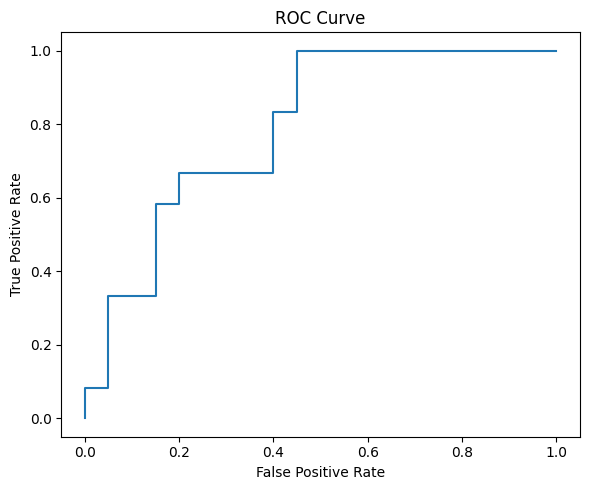

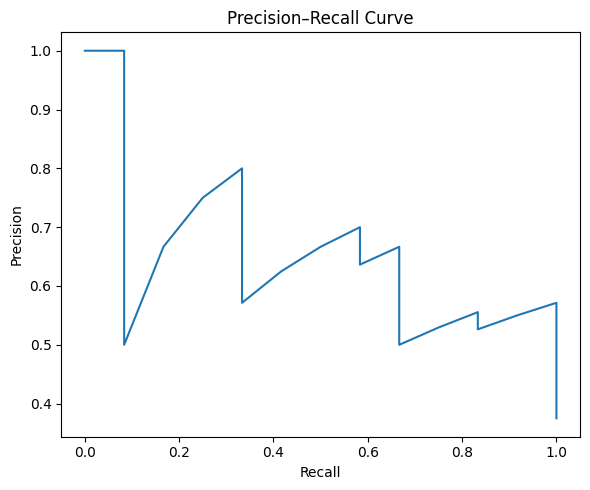

In [36]:
from sklearn.metrics import roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.tight_layout()
plt.show()

# --- Precision–Recall Curve ---
precisions, recalls, _ = precision_recall_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.tight_layout()
plt.show()
